In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [2]:
plt.style.use('dark_background')
params_personnalises = {
    'figure.facecolor': '#2F323A',
    'axes.facecolor': '#2F323A',
    'axes.edgecolor': '#D4D4D4',
    'axes.labelcolor': '#D4D4D4',
    'text.color': '#D4D4D4',
    'xtick.color': '#D4D4D4',
    'ytick.color': '#D4D4D4',
    'grid.color': '#3F424A',
    'font.family': 'monospace',
    'grid.linestyle': '--',
    'grid.alpha': 0.3
}
plt.rcParams.update(params_personnalises)

COULEURS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEEAD', 
            '#D4A5A5', '#9EC1CF', '#CC99C9', '#F94144', '#F3722C']

# Chargement et préparation des données

In [3]:
df = pd.read_csv("person_facial_features.csv")

encodeur = LabelEncoder()
etiquettes_personnes = encodeur.fit_transform(df['person_name'])

X_avec_noms = df.drop(["person_name", "image_path"], axis=1)

# Variables pour l'ACP
variables = X_avec_noms.columns.tolist()

# Matrice des données
X = X_avec_noms.values

# Définition des individus et caractéristiques
individus = df.index.tolist()
caracteristiques = variables

df_donnees = pd.DataFrame(X, index=individus, columns=caracteristiques)
print("Matrice des données:")
df_donnees.head()

Matrice des données:


,face_width,face_height,jaw_width,cheekbone_width,face_depth,jaw_angle,eye_socket_width,eye_socket_height,eye_spacing,eyebrow_position,eye_angle,nose_length,nose_width,nose_bridge_length,nose_angle,upper_face_ratio,middle_face_ratio,lower_face_ratio,face_width_height_ratio,eye_nose_ratio
0,2.283604,2.744604,2.206787,2.078771,1.201874,111.047915,0.487019,0.261402,0.538285,0.252452,114.519643,0.515209,0.513292,0.130701,1.896518,0.355383,0.187717,0.457624,0.832034,1.048690
1,2.259369,2.780144,2.181554,2.053019,1.230496,108.576887,0.467898,0.290178,0.545041,0.295925,106.389540,0.519735,0.521676,0.129772,0.951670,0.337247,0.186945,0.476207,0.812681,1.044789
2,2.279830,2.851437,2.224971,2.055276,1.250724,104.452428,0.425895,0.266996,0.535474,0.254854,110.376435,0.597022,0.507371,0.143506,1.005086,0.345453,0.209376,0.457231,0.799537,1.055389
3,2.105799,2.443657,1.994772,1.920813,1.160442,113.020285,0.453934,0.261192,0.564651,0.217571,101.309932,0.380521,0.486504,0.083435,4.184916,0.322108,0.155718,0.522740,0.861741,1.160629
4,2.189156,2.762989,2.108089,1.972978,1.262125,106.479267,0.435758,0.308127,0.540491,0.216196,102.528808,0.543187,0.513467,0.137799,1.896518,0.352249,0.196594,0.456676,0.792315,1.052632


# Calcul des statistiques de base

In [4]:
# Calcul de l'individu moyen
individu_moyen = np.mean(X, axis=0)
print("Individu moyen:")
pd.Series(individu_moyen, index=caracteristiques)

Individu moyen:


face_width                   2.260445
face_height                  2.775509
jaw_width                    2.198535
cheekbone_width              2.027961
face_depth                   1.227577
jaw_angle                  108.511042
eye_socket_width             0.442384
eye_socket_height            0.255533
eye_spacing                  0.555856
eyebrow_position             0.230081
eye_angle                  113.534877
nose_length                  0.499246
nose_width                   0.509073
nose_bridge_length           0.120040
nose_angle                   1.150845
upper_face_ratio             0.320094
middle_face_ratio            0.179754
lower_face_ratio             0.505986
face_width_height_ratio      0.816523
eye_nose_ratio               1.097516
dtype: float64

In [5]:
# Centrage des données
X_centre = X - individu_moyen
print("Matrice centrée:")
pd.DataFrame(X_centre, index=individus, columns=caracteristiques).head()

Matrice centrée:


,face_width,face_height,jaw_width,cheekbone_width,face_depth,jaw_angle,eye_socket_width,eye_socket_height,eye_spacing,eyebrow_position,eye_angle,nose_length,nose_width,nose_bridge_length,nose_angle,upper_face_ratio,middle_face_ratio,lower_face_ratio,face_width_height_ratio,eye_nose_ratio
0,0.023159,-0.030905,0.008251,0.050810,-0.025704,2.536873,0.044636,0.005869,-0.017571,0.022371,0.984766,0.015963,0.004219,0.010661,0.745673,0.035289,0.007963,-0.048361,0.015511,-0.048826
1,-0.001076,0.004635,-0.016981,0.025058,0.002918,0.065845,0.025515,0.034645,-0.010815,0.065844,-7.145336,0.020489,0.012603,0.009731,-0.199176,0.017153,0.007191,-0.029778,-0.003843,-0.052727
2,0.019385,0.075928,0.026435,0.027315,0.023146,-4.058614,-0.016489,0.011463,-0.020382,0.024773,-3.158441,0.097776,-0.001702,0.023466,-0.145759,0.025359,0.029622,-0.048755,-0.016986,-0.042127
3,-0.154646,-0.331852,-0.203763,-0.107148,-0.067136,4.509242,0.011551,0.005659,0.008795,-0.012510,-12.224944,-0.118725,-0.022569,-0.036606,3.034071,0.002014,-0.024036,0.016754,0.045218,0.063112
4,-0.071289,-0.012521,-0.090447,-0.054983,0.034548,-2.031775,-0.006626,0.052594,-0.015365,-0.013885,-11.006069,0.043941,0.004394,0.017758,0.745673,0.032155,0.016840,-0.049310,-0.024209,-0.044885


In [6]:
# Calcul de l'écart-type
ecart_type = np.std(X, axis=0, ddof=0)
print("Écart-type:")
pd.Series(ecart_type, index=caracteristiques)

Écart-type:


face_width                  0.075715
face_height                 0.178182
jaw_width                   0.089448
cheekbone_width             0.054446
face_depth                  0.060685
jaw_angle                   4.466122
eye_socket_width            0.043158
eye_socket_height           0.032026
eye_spacing                 0.012846
eyebrow_position            0.033304
eye_angle                  11.214443
nose_length                 0.063104
nose_width                  0.036491
nose_bridge_length          0.020479
nose_angle                  0.908722
upper_face_ratio            0.028408
middle_face_ratio           0.019104
lower_face_ratio            0.045321
face_width_height_ratio     0.038862
eye_nose_ratio              0.082629
dtype: float64

In [7]:
# Vérification des écarts-types nuls
indices_ecart_type_nul = np.where(ecart_type == 0)[0]
if len(indices_ecart_type_nul) > 0:
    print(f"Attention: Écart-type nul pour les variables: {[caracteristiques[i] for i in indices_ecart_type_nul]}")
    ecart_type[indices_ecart_type_nul] = 1e-10
else:
    print("Aucun écart-type nul détecté.")

Aucun écart-type nul détecté.


# Normalisation et calcul de la matrice de corrélation

In [8]:
# Calcul de la matrice centrée réduite (Z)
Z = X_centre / ecart_type
print("Matrice centrée réduite:")
pd.DataFrame(Z, index=individus, columns=caracteristiques).head()

Matrice centrée réduite:


,face_width,face_height,jaw_width,cheekbone_width,face_depth,jaw_angle,eye_socket_width,eye_socket_height,eye_spacing,eyebrow_position,eye_angle,nose_length,nose_width,nose_bridge_length,nose_angle,upper_face_ratio,middle_face_ratio,lower_face_ratio,face_width_height_ratio,eye_nose_ratio
0,0.305877,-0.173447,0.092247,0.933227,-0.423561,0.568026,1.034243,0.183260,-1.367802,0.671706,0.087812,0.252961,0.115625,0.520554,0.820573,1.242218,0.416823,-1.067074,0.399133,-0.590914
1,-0.014208,0.026013,-0.189845,0.460245,0.048089,0.014743,0.591197,1.081787,-0.841864,1.977047,-0.637155,0.324687,0.345356,0.475169,-0.219182,0.603790,0.376431,-0.657042,-0.098882,-0.638124
2,0.256025,0.426125,0.295537,0.501694,0.381416,-0.908756,-0.382062,0.357939,-1.586569,0.743831,-0.281641,1.549439,-0.046633,1.145825,-0.160400,0.892645,1.550579,-1.075758,-0.437094,-0.509839
3,-2.042480,-1.862434,-2.277997,-1.967979,-1.106302,1.009655,0.267640,0.176701,0.684614,-0.375630,-1.090107,-1.881404,-0.618469,-1.787439,3.338831,0.070903,-1.258200,0.369682,1.163558,0.763808
4,-0.941543,-0.070268,-1.011159,-1.009869,0.569293,-0.454930,-0.153520,1.642245,-1.196036,-0.416912,-0.981419,0.696322,0.120398,0.867128,0.820573,1.131874,0.881495,-1.088007,-0.622948,-0.543211


In [9]:
# Calcul de la matrice de corrélation
R = np.corrcoef(Z.T)
R_df = pd.DataFrame(R, columns=caracteristiques, index=caracteristiques)
print("Matrice de corrélation:")
R_df

Matrice de corrélation:


,face_width,face_height,jaw_width,cheekbone_width,face_depth,jaw_angle,eye_socket_width,eye_socket_height,eye_spacing,eyebrow_position,eye_angle,nose_length,nose_width,nose_bridge_length,nose_angle,upper_face_ratio,middle_face_ratio,lower_face_ratio,face_width_height_ratio,eye_nose_ratio
face_width,1.000000,0.634145,0.941376,0.858182,0.138833,-0.145494,0.056467,0.082916,-0.308150,0.079343,-0.023200,0.327287,0.075077,0.234011,-0.040198,-0.214843,0.003920,0.157563,-0.127072,-0.158919
face_height,0.634145,1.000000,0.621390,0.536597,0.852932,-0.406519,-0.164333,0.427026,-0.300926,0.109365,-0.406953,0.592934,-0.146958,0.480552,-0.025901,-0.094769,0.098890,0.125164,-0.840923,0.077981
jaw_width,0.941376,0.621390,1.000000,0.859982,0.161334,-0.202159,-0.014800,0.041060,-0.158491,0.119531,-0.081914,0.201423,0.139022,0.113193,-0.006933,-0.418574,-0.145298,0.357849,-0.144835,-0.171571
cheekbone_width,0.858182,0.536597,0.859982,1.000000,0.109296,-0.163423,0.017034,0.019362,-0.276577,0.087810,-0.070212,0.251798,0.203063,0.177336,-0.028309,-0.209827,-0.027778,0.173036,-0.097773,-0.267363
face_depth,0.138833,0.852932,0.161334,0.109296,1.000000,-0.425572,-0.249930,0.490320,-0.184375,0.080797,-0.504855,0.539614,-0.241617,0.457738,-0.008602,0.022664,0.125565,0.053119,-0.994602,0.207822
jaw_angle,-0.145494,-0.406519,-0.202159,-0.163423,-0.425572,1.000000,0.775524,-0.078811,-0.069321,0.310614,0.500492,-0.203867,0.522123,-0.171359,-0.004389,0.056510,0.001065,-0.102145,0.415671,-0.535070
eye_socket_width,0.056467,-0.164333,-0.014800,0.017034,-0.249930,0.775524,1.000000,0.078956,-0.345888,0.494461,0.510251,0.031515,0.651340,0.029782,-0.042339,0.109217,0.147817,-0.164787,0.227324,-0.728559
eye_socket_height,0.082916,0.427026,0.041060,0.019362,0.490320,-0.078811,0.078956,1.000000,-0.312955,0.319863,-0.724425,0.246932,-0.247833,0.251414,0.041614,0.069608,0.032234,0.016198,-0.485253,0.157973
eye_spacing,-0.308150,-0.300926,-0.158491,-0.276577,-0.184375,-0.069321,-0.345888,-0.312955,1.000000,-0.006389,-0.046911,-0.558710,0.002902,-0.490967,0.123969,-0.442319,-0.501703,0.474511,0.202798,0.294387
eyebrow_position,0.079343,0.109365,0.119531,0.087810,0.080797,0.310614,0.494461,0.319863,-0.006389,1.000000,-0.050673,-0.069773,0.364750,-0.070363,0.066743,-0.203929,-0.159210,0.226351,-0.074320,-0.331763


In [10]:
fichier_correlation = "matrice_correlation.csv"
R_df.to_csv(fichier_correlation)
print(f"Matrice de corrélation sauvegardée dans {fichier_correlation}")

if np.isnan(R).any() or np.isinf(R).any():
    print("Attention: Valeurs NaN ou inf trouvées dans la matrice de corrélation. Remplacement par zéros.")
    R = np.nan_to_num(R)
else:
    print("Aucune valeur NaN ou inf détectée.")

Matrice de corrélation sauvegardée dans matrice_correlation.csv
Aucune valeur NaN ou inf détectée.


# Calcul et analyse des valeurs propres

In [11]:
# Calcul des valeurs propres et vecteurs propres
valeurs_propres, vecteurs_propres = np.linalg.eig(R)
valeurs_propres = np.real(valeurs_propres)
vecteurs_propres = np.real(vecteurs_propres)

idx = valeurs_propres.argsort()[::-1]
valeurs_propres = valeurs_propres[idx]
vecteurs_propres = vecteurs_propres[:, idx]

print("Valeurs propres triées:")
print(valeurs_propres)

Valeurs propres triées:
[5.38884144e+00 4.43523276e+00 3.70826559e+00 2.07551470e+00
 1.11472368e+00 9.50259386e-01 6.04296431e-01 5.62558517e-01
 3.96281545e-01 2.80467445e-01 1.78764042e-01 1.33112337e-01
 7.61289644e-02 4.24443649e-02 2.94536889e-02 1.37133873e-02
 5.25862824e-03 3.01731057e-03 1.23852939e-03 4.27258857e-04]


In [12]:
# Calcul de l'inertie
inertie = valeurs_propres / np.sum(valeurs_propres)
inertie_cumulee = np.cumsum(inertie)

tableau_resultats = pd.DataFrame({
    "Valeurs propres": np.round(valeurs_propres, 4),
    "Inertie (%)": np.round(inertie * 100, 4),
    "Inertie cumulée (%)": np.round(inertie_cumulee * 100, 4),
})
print("Tableau des valeurs propres et inerties:")
tableau_resultats

Tableau des valeurs propres et inerties:


,Valeurs propres,Inertie (%),Inertie cumulée (%)
0,5.3888,26.9442,26.9442
1,4.4352,22.1762,49.1204
2,3.7083,18.5413,67.6617
3,2.0755,10.3776,78.0393
4,1.1147,5.5736,83.6129
5,0.9503,4.7513,88.3642
6,0.6043,3.0215,91.3857
7,0.5626,2.8128,94.1985
8,0.3963,1.9814,96.1799
9,0.2805,1.4023,97.5822


# Visualisation de l'éboulis des valeurs propres

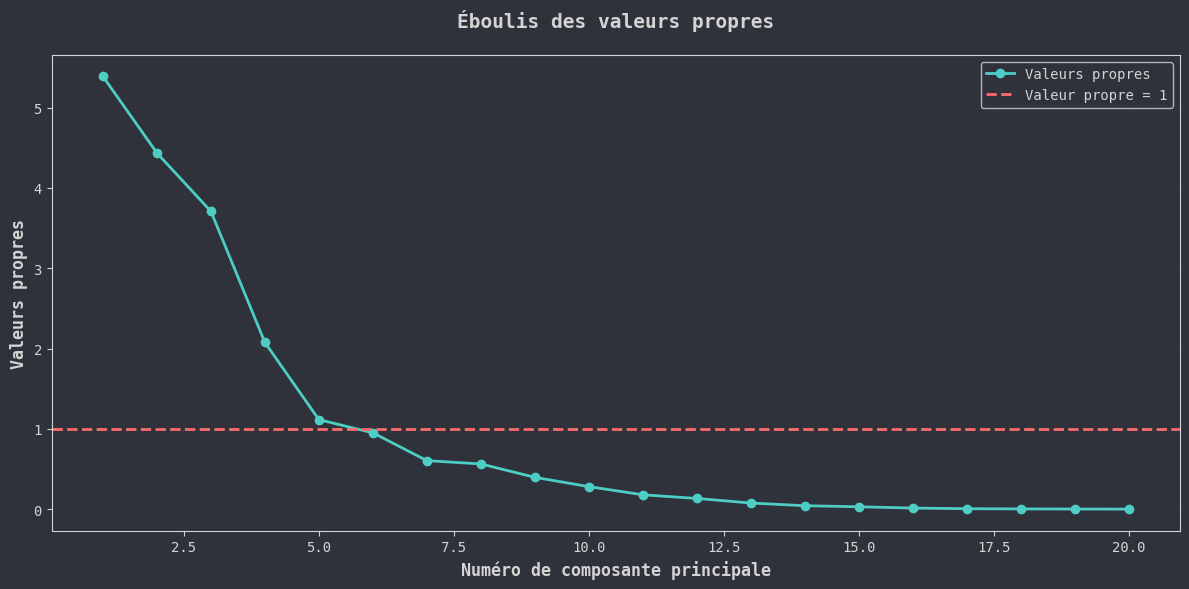

In [13]:
n_composantes = min(128, len(valeurs_propres))
plt.figure(figsize=(12, 6))
plt.plot(
    range(1, n_composantes + 1),
    valeurs_propres[:n_composantes],
    marker="o",
    linestyle="-",
    color='#4ECDC4',
    linewidth=2,
    markersize=6,
    label="Valeurs propres"
)
plt.axhline(y=1, color='#FF6B6B', linestyle='--', label="Valeur propre = 1", linewidth=2)
plt.xlabel("Numéro de composante principale", fontsize=12, fontweight='bold')
plt.ylabel("Valeurs propres", fontsize=12, fontweight='bold')
plt.title("Éboulis des valeurs propres", fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, facecolor='#2F323A', edgecolor='#D4D4D4')
plt.tight_layout()
plt.savefig('eboulis_valeurs_propres.png', dpi=300, bbox_inches='tight', facecolor='#2F323A')
plt.show()

# Projections des individus sur les composantes principales

In [14]:
# Calcul des coordonnées des individus dans l'espace des composantes principales
nb_comp = 5 
projections = np.dot(Z, vecteurs_propres[:, :nb_comp])

# Création du tableau des projections
noms_colonnes = [f"CP{i+1}" for i in range(nb_comp)]
tableau_projections = pd.DataFrame(
    projections[:, :nb_comp],
    index=df['person_name'],
    columns=noms_colonnes
)

print(f"Tableau des projections des individus sur les {nb_comp} premières composantes principales:")
tableau_projections


Tableau des projections des individus sur les 5 premières composantes principales:


,CP1,CP2,CP3,CP4,CP5
person_name,,,,,
Ariel_Sharon,0.551327,-2.087414,0.791584,-0.188407,1.476759
Ariel_Sharon,0.975822,-1.115678,0.722924,-1.587578,1.016141
Ariel_Sharon,2.841181,-1.690224,-0.019293,0.148340,0.355687
Ariel_Sharon,-4.276726,1.100261,-2.877703,-2.004382,1.464527
Ariel_Sharon,1.748796,-1.348841,-1.796025,-1.645460,0.512889
...,...,...,...,...,...
Tony_Blair,0.679500,0.219565,-0.471046,-0.050576,1.376763
Tony_Blair,1.270584,-0.785649,0.225047,0.076066,0.830691
Tony_Blair,2.505381,-0.301127,0.117094,0.399765,1.063168


# Analyse des contributions des individus

In [15]:
# Calcul des contributions des individus (en pourcentage)
n_individus = len(df)
contributions_individus = (projections[:, :nb_comp] ** 2) / (n_individus * valeurs_propres[:nb_comp])
contributions_individus *= 100  # Conversion en pourcentage

tableau_contributions = pd.DataFrame(
    contributions_individus,
    index=df['person_name'],
    columns=[f"Contribution CP{i+1} (%)" for i in range(nb_comp)]
)

print("Tableau des contributions des individus (en %):")
tableau_contributions

Tableau des contributions des individus (en %):


,Contribution CP1 (%),Contribution CP2 (%),Contribution CP3 (%),Contribution CP4 (%),Contribution CP5 (%)
person_name,,,,,
Ariel_Sharon,0.004383,0.076335,0.013129,0.001329,0.152011
Ariel_Sharon,0.013730,0.021806,0.010951,0.094355,0.071972
Ariel_Sharon,0.116392,0.050049,0.000008,0.000824,0.008818
Ariel_Sharon,0.263723,0.021208,0.173517,0.150403,0.149503
Ariel_Sharon,0.044097,0.031873,0.067589,0.101361,0.018336
...,...,...,...,...,...
Tony_Blair,0.006657,0.000845,0.004649,0.000096,0.132121
Tony_Blair,0.023277,0.010813,0.001061,0.000217,0.048099
Tony_Blair,0.090505,0.001589,0.000287,0.005983,0.078788


In [16]:
# Calcul des moyennes des contributions par composante
moyennes_contributions = np.mean(contributions_individus, axis=0)
print("Moyennes des contributions par composante principale:")
for i, moy in enumerate(moyennes_contributions):
    print(f"CP{i+1}: {moy:.2f}%")

Moyennes des contributions par composante principale:
CP1: 0.08%
CP2: 0.08%
CP3: 0.08%
CP4: 0.08%
CP5: 0.08%


# Analyse des contributions des variables

In [17]:
# Calcul des contributions des variables
contributions_variables = vecteurs_propres[:, :nb_comp]**2
contributions_variables = pd.DataFrame(
    contributions_variables * 100,
    index=caracteristiques,
    columns=[f"Contribution CP{i+1} (%)" for i in range(nb_comp)]
)

print("Tableau des contributions des variables (en %):")
contributions_variables

Tableau des contributions des variables (en %):


,Contribution CP1 (%),Contribution CP2 (%),Contribution CP3 (%),Contribution CP4 (%),Contribution CP5 (%)
face_width,3.763854,0.376260,13.483743,8.441474,4.522102
face_height,13.521059,1.907822,3.214829,0.200721,2.332461
jaw_width,2.503405,1.863795,15.624539,7.231581,0.959094
cheekbone_width,2.708178,0.348085,13.952311,8.125078,2.394360
face_depth,11.634228,1.835559,0.034656,6.311644,11.472051
jaw_angle,4.455632,6.098684,2.504666,5.748106,1.528772
eye_socket_width,1.015646,8.659095,7.155633,8.455408,1.340592
eye_socket_height,4.706325,0.758340,0.004467,19.120923,19.849467
eye_spacing,4.892102,5.356513,0.805739,0.060185,13.231196
eyebrow_position,0.070780,0.008357,5.967988,19.107863,0.910864


In [18]:
# Calcul des moyennes des contributions des variables par composante
moyennes_contributions_var = np.mean(contributions_variables, axis=0)
print("Moyennes des contributions des variables par composante principale:")
for i, moy in enumerate(moyennes_contributions_var):
    print(f"CP{i+1}: {moy:.2f}%")


Moyennes des contributions des variables par composante principale:
CP1: 5.00%
CP2: 5.00%
CP3: 5.00%
CP4: 5.00%
CP5: 5.00%


In [19]:
tableau_contributions.to_csv("contributions_individus.csv")
contributions_variables.to_csv("contributions_variables.csv")
print("Tableaux des contributions sauvegardés dans:")
print("- contributions_individus.csv")
print("- contributions_variables.csv")

Tableaux des contributions sauvegardés dans:
- contributions_individus.csv
- contributions_variables.csv


# Qualité de représentation (cos²)

In [20]:
# Calcul de la qualité de représentation (cos²)
cos2_individus = (projections[:, :nb_comp] ** 2) / np.sum(projections ** 2, axis=1)[:, np.newaxis]
tableau_cos2 = pd.DataFrame(
    cos2_individus,
    index=df['person_name'],
    columns=[f"cos²_CP{i+1}" for i in range(nb_comp)]
)

print("Qualité de représentation des individus (cos²):")
tableau_cos2.round(4)

Qualité de représentation des individus (cos²):


,cos²_CP1,cos²_CP2,cos²_CP3,cos²_CP4,cos²_CP5
person_name,,,,,
Ariel_Sharon,0.0405,0.5806,0.0835,0.0047,0.2906
Ariel_Sharon,0.1518,0.1984,0.0833,0.4018,0.1646
Ariel_Sharon,0.7287,0.2579,0.0000,0.0020,0.0114
Ariel_Sharon,0.5388,0.0357,0.2440,0.1184,0.0632
Ariel_Sharon,0.2762,0.1643,0.2913,0.2445,0.0238
...,...,...,...,...,...
Tony_Blair,0.1756,0.0183,0.0844,0.0010,0.7208
Tony_Blair,0.5421,0.2073,0.0170,0.0019,0.2317
Tony_Blair,0.8182,0.0118,0.0018,0.0208,0.1473


In [21]:
tableau_cos2.to_csv("qualite_representation.csv")
print("Qualité de représentation sauvegardée dans qualite_representation.csv")

Qualité de représentation sauvegardée dans qualite_representation.csv


# Visualisation 3D des individus

Création de la projection 3D sur les trois premières composantes principales...


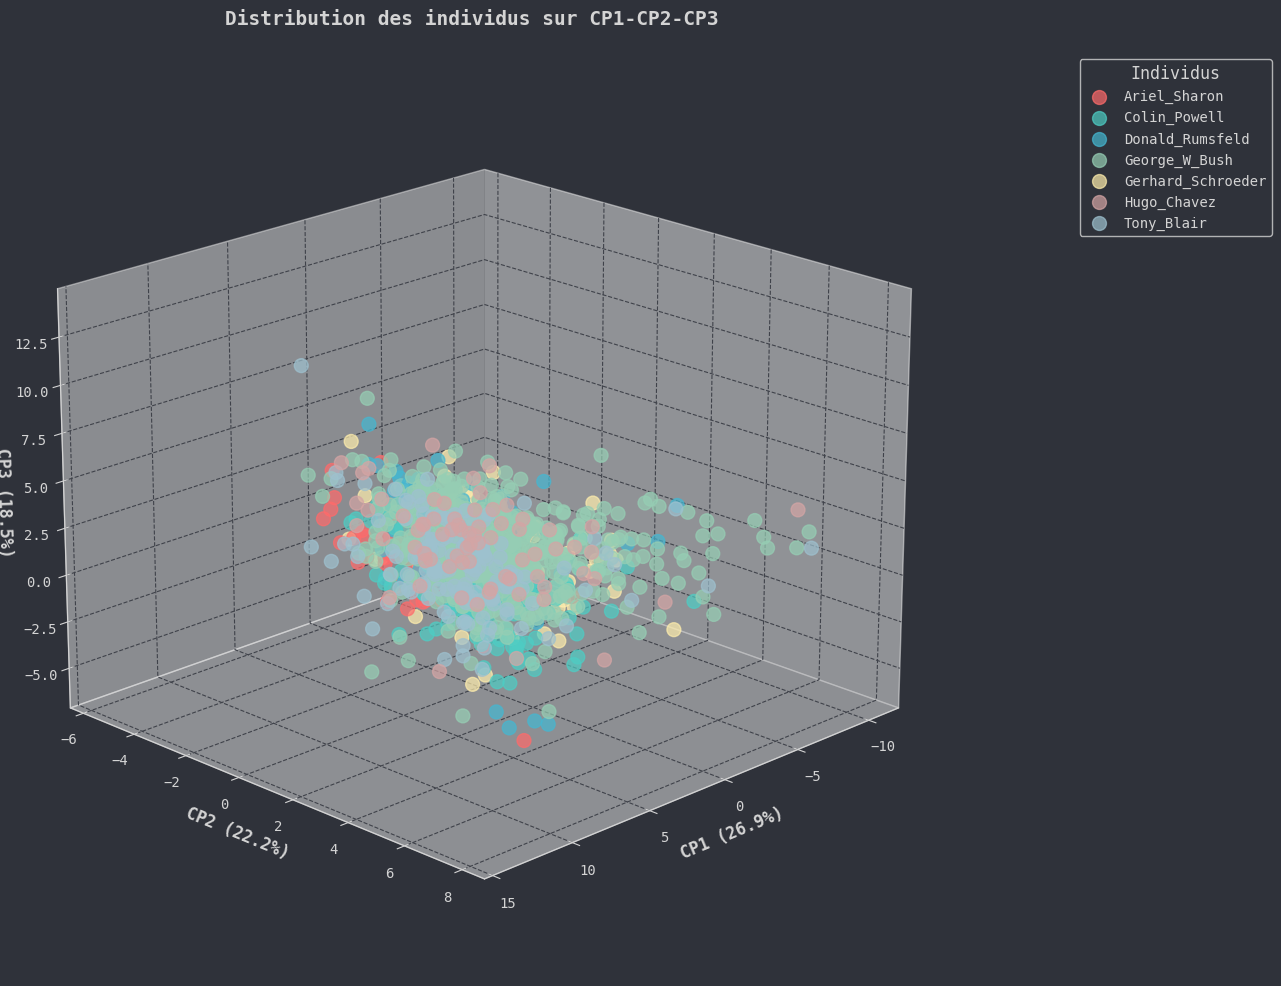

Distribution 3D des individus sauvegardée dans distribution_individus_3d.png


In [22]:
personnes_uniques = df['person_name'].unique()
couleurs_personnes = COULEURS[:len(personnes_uniques)]
person_color_dict = dict(zip(personnes_uniques, couleurs_personnes))

# Projection 3D sur les trois premières composantes principales
print("Création de la projection 3D sur les trois premières composantes principales...")
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')

projections_3d = np.dot(Z, vecteurs_propres[:, :3]) 

for personne, couleur in person_color_dict.items():
    masque = df['person_name'] == personne
    ax.scatter(
        projections_3d[masque, 0],
        projections_3d[masque, 1],
        projections_3d[masque, 2],
        c=[couleur],
        label=personne,
        alpha=0.7,
        s=100
    )

ax.set_xlabel(f'CP1 ({inertie[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'CP2 ({inertie[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'CP3 ({inertie[2]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('Distribution des individus sur CP1-CP2-CP3', 
             fontsize=14, fontweight='bold', pad=20)

legende = ax.legend(title="Individus", bbox_to_anchor=(1.15, 1),
                   loc='upper left', frameon=True, facecolor='#2F323A',
                   edgecolor='#D4D4D4', title_fontsize=12)
legende.get_title().set_color('#D4D4D4')

ax.set_facecolor('#2F323A')
fig.patch.set_facecolor('#2F323A')
ax.grid(True, alpha=0.2)

ax.view_init(elev=20, azim=45) 

plt.savefig('distribution_individus_3d.png', dpi=300, bbox_inches='tight', facecolor='#2F323A')
plt.show()

print("Distribution 3D des individus sauvegardée dans distribution_individus_3d.png")

# Test de classification avec différents nombres de composantes

In [23]:
n_composantes_liste = [2, 3, 4, 7]
resultats_classification = {}

for n_comp in n_composantes_liste:
    print(f"Analyse avec {n_comp} composantes principales:")
    
    # Projection des données sur les composantes principales
    vecteurs_n = vecteurs_propres[:, :n_comp]
    projections_n = np.dot(Z, vecteurs_n)
    
    X_train, X_test, y_train, y_test = train_test_split(
        projections_n, etiquettes_personnes, test_size=0.2, random_state=42
    )
  
    clf = KNeighborsClassifier(n_neighbors=3)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    resultats_classification[n_comp] = accuracy
    
    print(f"Précision de la classification avec {n_comp} composantes: {accuracy:.4f}")

Analyse avec 2 composantes principales:
Précision de la classification avec 2 composantes: 0.3333
Analyse avec 3 composantes principales:
Précision de la classification avec 3 composantes: 0.4457
Analyse avec 4 composantes principales:
Précision de la classification avec 4 composantes: 0.5039
Analyse avec 7 composantes principales:
Précision de la classification avec 7 composantes: 0.4961


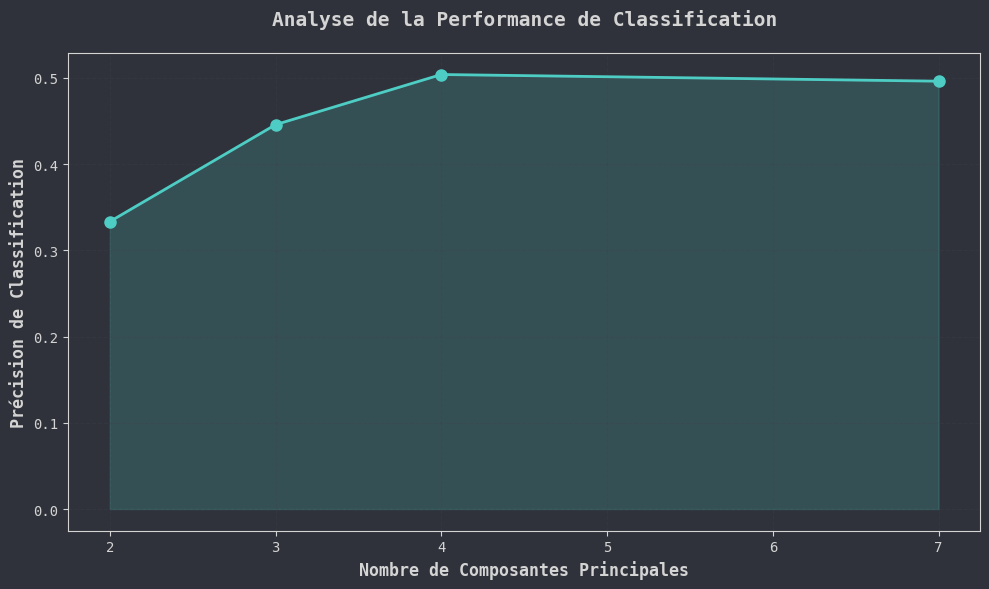

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(list(resultats_classification.keys()), 
         list(resultats_classification.values()), 
         marker='o', linestyle='-', color='#4ECDC4',
         linewidth=2, markersize=8)
plt.fill_between(list(resultats_classification.keys()),
                list(resultats_classification.values()),
                alpha=0.2, color='#4ECDC4')
plt.xlabel('Nombre de Composantes Principales', fontsize=12, fontweight='bold')
plt.ylabel('Précision de Classification', fontsize=12, fontweight='bold')
plt.title('Analyse de la Performance de Classification', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultats_classification.png', dpi=300, 
            bbox_inches='tight', facecolor='#2F323A')
plt.show()

# Analyse de la variance expliquée

In [25]:
target_variance = 0.80
n_components_80 = np.argmax(inertie_cumulee >= target_variance) + 1
print(f"Number of components needed for {target_variance*100}% variance: {n_components_80}")

print("\nCumulative Explained Variance:")
for i in range(min(10, len(inertie_cumulee))):
    print(f"First {i+1} components: {inertie_cumulee[i]*100:.2f}%")

Number of components needed for 80.0% variance: 5

Cumulative Explained Variance:
First 1 components: 26.94%
First 2 components: 49.12%
First 3 components: 67.66%
First 4 components: 78.04%
First 5 components: 83.61%
First 6 components: 88.36%
First 7 components: 91.39%
First 8 components: 94.20%
First 9 components: 96.18%
First 10 components: 97.58%


# Visualisation de la sphère des corrélations 3D

In [26]:
def tracer_sphere_correlation_3d(vecteurs_propres, valeurs_propres, caracteristiques):
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(111, projection='3d')
    
    # Calcul des coordonnées des variables
    coords = vecteurs_propres[:, :3] * np.sqrt(valeurs_propres[:3])

    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))

    ax.plot_surface(x, y, z, color='gray', alpha=0.1)

    ax.plot([-1, 1], [0, 0], [0, 0], 'gray', alpha=0.5)
    ax.plot([0, 0], [-1, 1], [0, 0], 'gray', alpha=0.5) 
    ax.plot([0, 0], [0, 0], [-1, 1], 'gray', alpha=0.5)

    for i, (var, coord) in enumerate(zip(caracteristiques, coords)):
        color = COULEURS[i % len(COULEURS)]
        ax.quiver(0, 0, 0, coord[0], coord[1], coord[2],
                 color=color, alpha=0.8, arrow_length_ratio=0.1)

        ax.text(coord[0]*1.1, coord[1]*1.1, coord[2]*1.1,
                var.replace('_', ' ').title(),
                color=color, fontsize=8)
        
    ax.set_xlabel(f'CP1 ({inertie[0]*100:.1f}%)', fontsize=12, labelpad=10)
    ax.set_ylabel(f'CP2 ({inertie[1]*100:.1f}%)', fontsize=12, labelpad=10)
    ax.set_zlabel(f'CP3 ({inertie[2]*100:.1f}%)', fontsize=12, labelpad=10)

    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])

    plt.title('Sphère des Corrélations 3D', fontsize=14, pad=20)

    ax.view_init(elev=20, azim=45)

    ax.set_facecolor('#2F323A')
    fig.patch.set_facecolor('#2F323A')
    
    return fig

Création de la sphère des corrélations 3D (vue isométrique)...


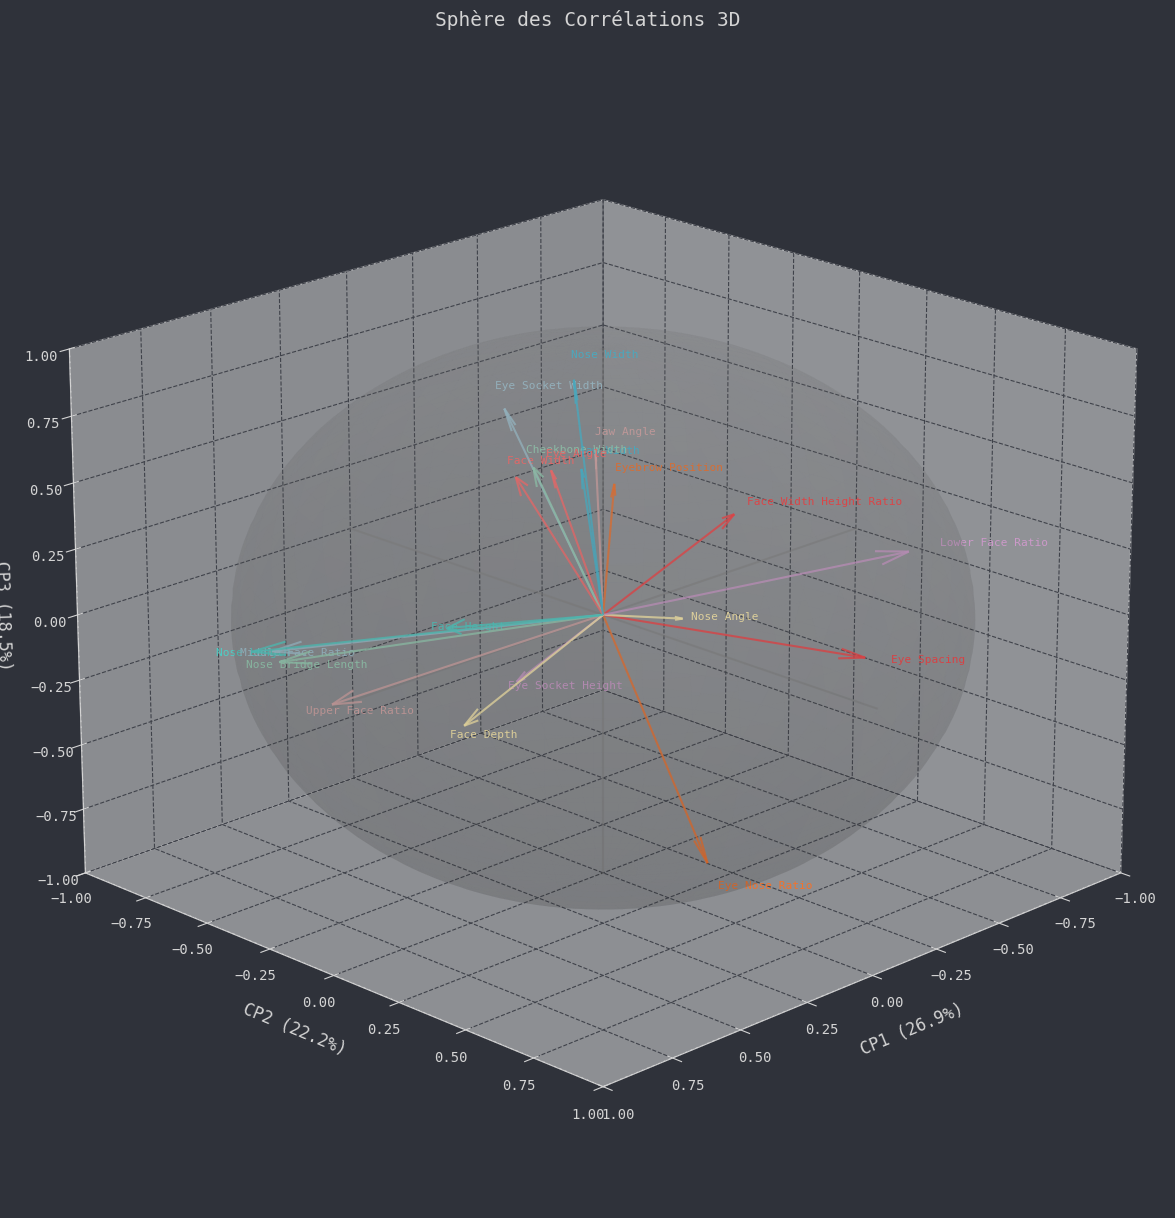

In [27]:
print("Création de la sphère des corrélations 3D (vue isométrique)...")
fig_sphere = tracer_sphere_correlation_3d(vecteurs_propres, valeurs_propres, caracteristiques)
plt.savefig('sphere_correlations_3d.png', dpi=300, bbox_inches='tight', facecolor='#2F323A')
plt.show()

Création de la sphère des corrélations 3D (vue de côté)...


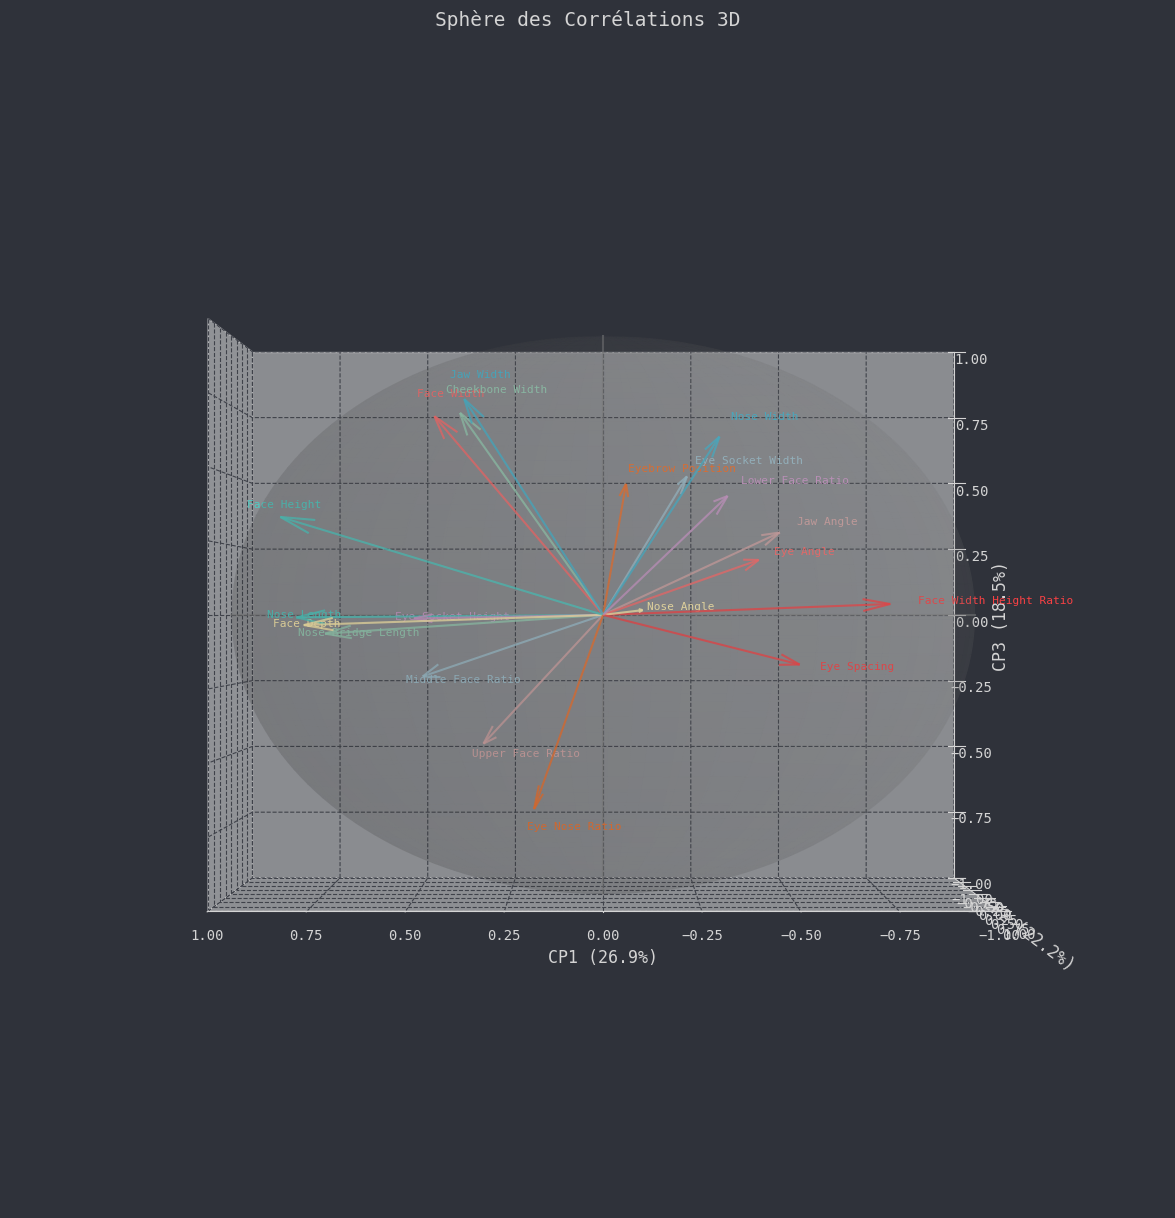

In [28]:
print("Création de la sphère des corrélations 3D (vue de côté)...")
fig_sphere_alt = tracer_sphere_correlation_3d(vecteurs_propres, valeurs_propres, caracteristiques)
plt.gca().view_init(elev=0, azim=90)
plt.savefig('sphere_correlations_3d_vue2.png', dpi=300, bbox_inches='tight', facecolor='#2F323A')
plt.show()

Création de la sphère des corrélations 3D (vue de dessus)...


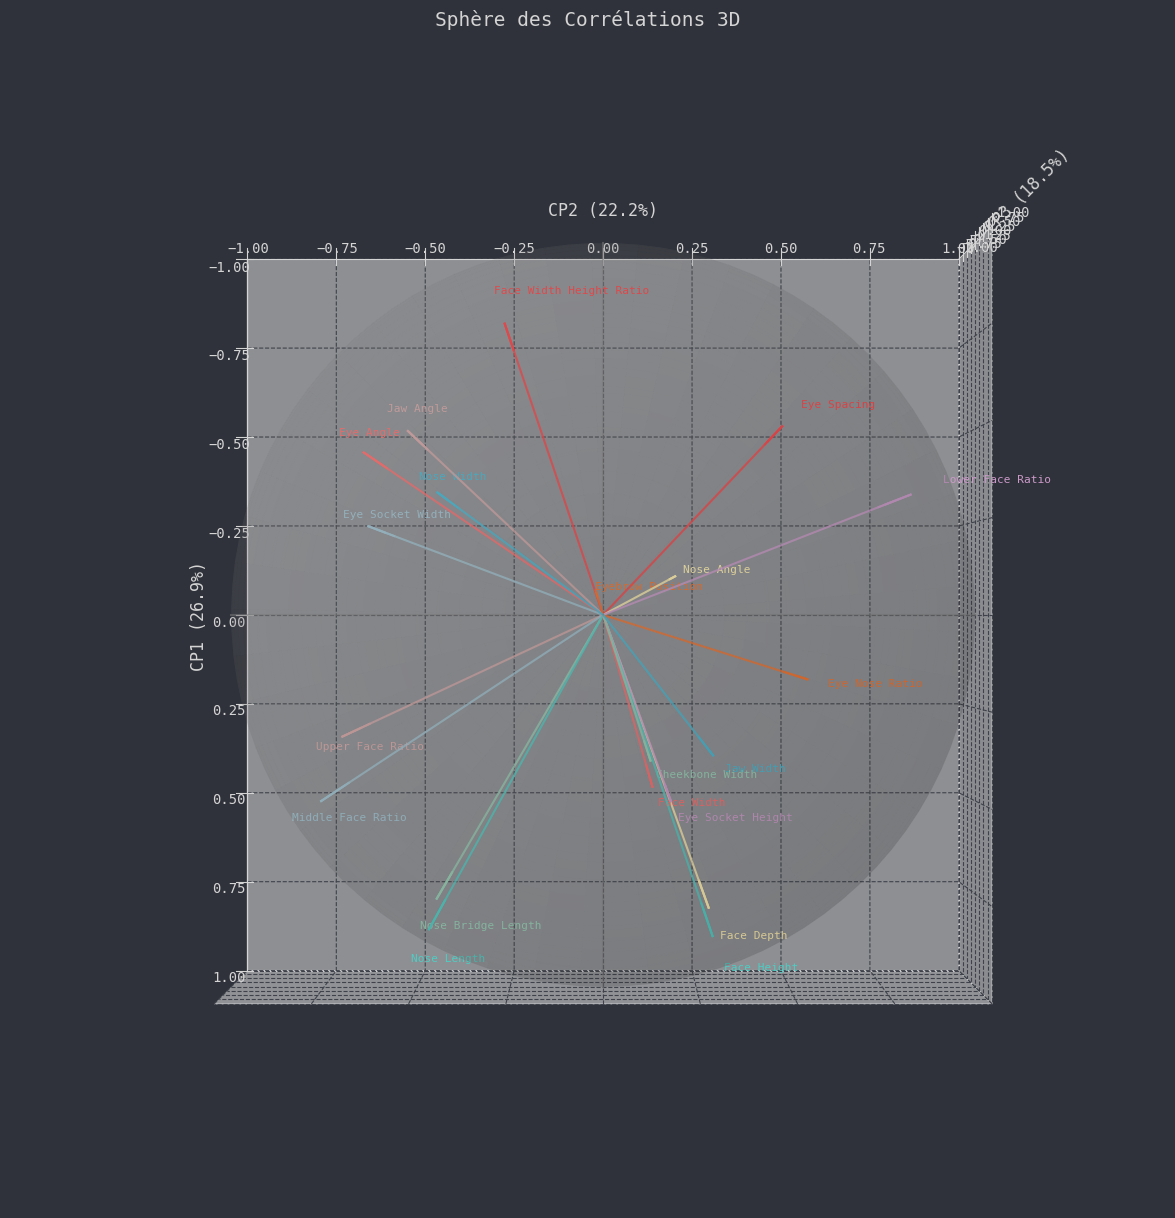

Sphère des corrélations sauvegardée sous trois angles différents:
- sphere_correlations_3d.png (vue isométrique)
- sphere_correlations_3d_vue2.png (vue de côté)
- sphere_correlations_3d_vue3.png (vue de dessus)


In [29]:
print("Création de la sphère des corrélations 3D (vue de dessus)...")
fig_sphere_alt2 = tracer_sphere_correlation_3d(vecteurs_propres, valeurs_propres, caracteristiques)
plt.gca().view_init(elev=90, azim=0)
plt.savefig('sphere_correlations_3d_vue3.png', dpi=300, bbox_inches='tight', facecolor='#2F323A')
plt.show()

print("Sphère des corrélations sauvegardée sous trois angles différents:")
print("- sphere_correlations_3d.png (vue isométrique)")
print("- sphere_correlations_3d_vue2.png (vue de côté)")
print("- sphere_correlations_3d_vue3.png (vue de dessus)")